In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans

In [2]:
import os
os.chdir("../")
%pwd

'd:\\Projects\\Playfield_Vision'

In [3]:
image_path = "output_videos\save_video_demo\cropped_image_1.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

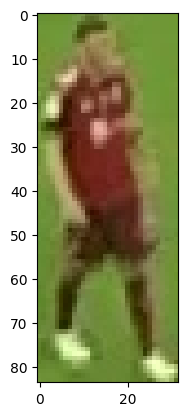

In [4]:
plt.imshow(image)
plt.show()

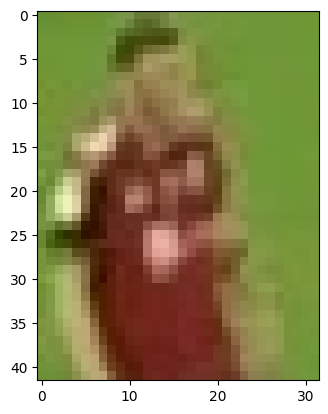

In [5]:
# Take top half of the cropped image 
top_half = image[0 : int(image.shape[0] / 2), : ]
plt.imshow(top_half)
plt.show()

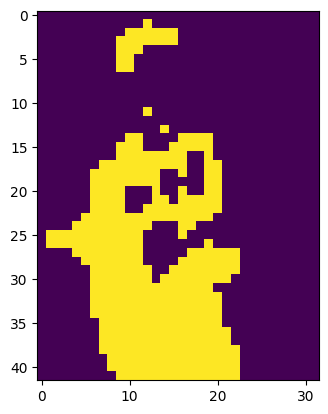

In [6]:
# Now as we two major color so we need to cluster both ground color and jersey color into two different colors and take average of the jersey color

# To do so we will firstly convert the array into the 2d array
image_2d = top_half.reshape(-1 , 3)

# Applying KMeans Clustering
kmeans = KMeans(n_clusters= 2, random_state=0)
kmeans.fit(image_2d)

# Get labels of the cluster
labels = kmeans.labels_


# reshape the lables into original image 
clustered_image = labels.reshape(top_half.shape[0], top_half.shape[1])

plt.imshow(clustered_image)
plt.show()

In [7]:
# as kmeans assigns cluters and we have to get the corner of the box and assign majority as the outer cluster and other label as the segmented image cluster
# here -1 is just the last element
corner_cluster = [clustered_image[0,0] , clustered_image[0, -1], clustered_image[1, 0] , clustered_image[-1,-1]]

non_player_cluster = max(set(corner_cluster), key = corner_cluster.count)
print(non_player_cluster)

# print(labels)


0


In [8]:
# player cluster is out of 1 
player_cluster = 1 - non_player_cluster

print(player_cluster)

1


In [9]:
# now we can get the center value of the cluster to get the color of the player_cluster
kmeans.cluster_centers_[player_cluster]

array([102.98167539,  50.59947644,  27.9921466 ])

In [10]:
# and  Now we can assign team Memebers